# model
credit: https://github.com/karpathy/ng-video-lecture

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 128 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.1
# ------------

torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('shuffled_novel.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(vocab_size)

# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)
        # print(sum(p.numel() for p in self.token_embedding_table.parameters()))

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

5968


# train

In [ ]:
model = BigramLanguageModel()
# model.load_state_dict(torch.load('model_checkpoint_4999.pth'))
# print("Loaded model from checkpoint.")
m = model.to(device)
# print the number of parameters in the model
# print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

t = [p for p in m.parameters()]
# print(len(t))

if 1 == 1:
    # create a PyTorch optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    for iter in range(0, 50001):

        # every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss()
            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        if iter % 10000 == 0 or iter == max_iters - 1:
            # Save the model at regular intervals
            torch.save(model.state_dict(), f'checkpoint2_shuffled_dropout_{iter:05d}.pth')
            print(f"Model checkpoint saved at step {iter}.")

        # sample a batch of data
        xb, yb = get_batch('train')

        # evaluate the loss
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # generate from the model
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))

# load pre-trained model 

In [5]:
try:
    model = BigramLanguageModel()
    # model.load_state_dict(torch.load('checkpoint2_shuffled_dropout_50000.pth'))
    model.load_state_dict(torch.load('checkpoint2_shuffled_dropout_50000.pth', map_location=device))
    model = model.to(device)
    print("Loaded model from checkpoint.")
except FileNotFoundError:
    model = BigramLanguageModel().to(device)
    print("No checkpoint found. Training from scratch.")

    
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

# context = torch.zeros((1, 1), dtype=torch.long, device=device)
# context = torch.tensor([encode('诸葛亮')], device=device)
# print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))

Loaded model from checkpoint.
18.787152 M parameters


# inference

In [7]:
context = torch.tensor([encode('宋公明')], device=device)
print(decode(model.generate(context, max_new_tokens=2)[0].tolist()))

torch.Size([1, 3, 64])
torch.Size([1, 3, 64])
torch.Size([1, 3, 64])
torch.Size([1, 3, 64])
torch.Size([1, 4, 64])
torch.Size([1, 4, 64])
torch.Size([1, 4, 64])
torch.Size([1, 4, 64])
宋公明，诸


In [13]:
# self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
# wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)

import torch
from torch.nn import functional as F

block_size = 10
T = 5

wei = torch.rand(5, 5)
# print(wei)

tri = torch.tril(torch.ones(block_size, block_size))

wei2 = wei.masked_fill(tri[:T, :T] == 0, float('-inf'))
F.softmax(wei2, dim=-1)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3793, 0.6207, 0.0000, 0.0000, 0.0000],
        [0.5063, 0.3003, 0.1934, 0.0000, 0.0000],
        [0.3052, 0.2067, 0.3026, 0.1856, 0.0000],
        [0.1615, 0.1439, 0.2124, 0.2066, 0.2756]])

# 位置编码

输入张量形状: torch.Size([2, 10, 64])
添加位置编码后形状: torch.Size([2, 10, 64])


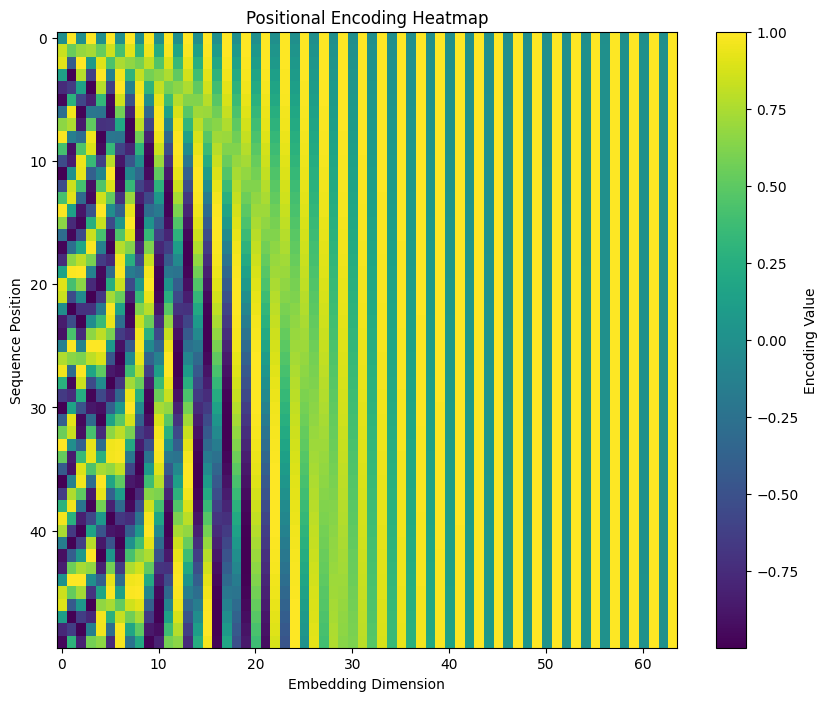

In [2]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

class FixedPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_seq_len: int = 5000):
        """
        固定位置编码（基于正弦和余弦函数）。
        Args:
            d_model (int): 嵌入维度（即模型的特征维度）。
            max_seq_len (int): 支持的最大序列长度。
        """
        super().__init__()
        self.d_model = d_model
        
        # 生成位置编码矩阵 (shape: [max_seq_len, d_model])
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)  # [max_seq_len, 1]
        
        # 计算缩放因子：10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # [d_model/2]
        
        # 填充位置编码矩阵
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度用正弦
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度用余弦
        
        # 注册为模型的缓冲区（不参与训练）
        self.register_buffer('pe', pe.unsqueeze(0))  # shape: [1, max_seq_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        将位置编码添加到输入张量中。
        Args:
            x: 输入张量，形状为 [batch_size, seq_len, d_model]
        Returns:
            输出张量：x + 位置编码
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]  # 自动广播到 batch_size
        return x

# 示例用法
d_model = 64    # 嵌入维度
max_seq_len = 100  # 最大序列长度
pe = FixedPositionalEncoding(d_model, max_seq_len)

# 生成一个虚拟输入（batch_size=2, seq_len=10, d_model=64）
x = torch.randn(2, 10, d_model)
x_with_pe = pe(x)  # 添加位置编码

print("输入张量形状:", x.shape)             # [2, 10, 64]
print("添加位置编码后形状:", x_with_pe.shape)  # [2, 10, 64]



def plot_positional_encoding_heatmap(pe_matrix: torch.Tensor):
    """
    绘制位置编码的热力图。
    Args:
        pe_matrix: 位置编码矩阵，形状为 [max_seq_len, d_model]
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(pe_matrix.numpy(), cmap='viridis', aspect='auto')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Sequence Position')
    plt.colorbar(label='Encoding Value')
    plt.title('Positional Encoding Heatmap')
    plt.show()

# 提取位置编码矩阵（前 50 个位置）
pe_matrix = pe.pe.squeeze(0)[:50, :]  # [50, 64]
plot_positional_encoding_heatmap(pe_matrix)